# AI experiments: which approach fits the problem best?

Goal: grow card usage in e-commerce. Three AI approaches are compared on the same data and time split:

| # | Approach | Business question |
|---|---|---|
| A | Readiness model (see `readiness_model.ipynb`) | *Who* will start paying online in the next 3 months? |
| B | Behavioural clustering (in-store behaviour only) | *What kinds* of customers exist, and which kinds are under-served online? |
| C | First-purchase recommender | *What* will a new online customer buy first, i.e. which offer to show? |

Time split (same as the readiness model): **train window** Mar-Aug 2025 (snapshot T = Sep 2025),
**test window** Sep 2025-Feb 2026 (snapshot T = Mar 2026). Labels come from the 3 months after T.

Everything shown is aggregated to groups of at least 30 cards. Data are synthetic.

In [1]:
from pathlib import Path

import duckdb
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, roc_auc_score, silhouette_score
from sklearn.preprocessing import StandardScaler

from paths import CACHE, DATA
PANEL = (CACHE / "card_month_panel").as_posix()
FIRST_ONLINE = (CACHE / "card_first_online").as_posix()
SLIM = (CACHE / "slim").as_posix()
FEATURES = CACHE / "card_window_features.parquet"
N_BUCKETS = 16
MIN_CARDS = 30
TRAIN_T, TEST_T = 8, 14
RNG = 42

con = duckdb.connect()
con.sql("SET memory_limit = '4GB'")
con.sql("SET threads = 4")
con.sql(f"CREATE OR REPLACE VIEW panel AS SELECT *, (month // 100 - 2025) * 12 + month % 100 - 1 AS m FROM read_parquet('{PANEL}/*.parquet')")
con.sql(f"CREATE OR REPLACE VIEW first_online AS SELECT * FROM read_parquet('{FIRST_ONLINE}/*.parquet')")

pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})
pct = mtick.PercentFormatter(100)

def safe(df, cards_col="cards"):
    return df[df[cards_col] >= MIN_CARDS].copy()

def yyyymm(m):
    return (2025 + m // 12) * 100 + m % 12 + 1

NOT_SHOPPING_MCC = "(4829, 6012, 6051, 6211, 6538, 6540)"
IS_ONLINE = f"(cp_flag = 0 AND mrch_catg_cd NOT IN {NOT_SHOPPING_MCC})"

# Merchant category codes grouped into readable macro groups
MACRO = '''
CASE
  WHEN mrch_catg_cd IN (5411, 5422, 5441, 5451, 5462, 5499, 5921) THEN 'grocery'
  WHEN mrch_catg_cd IN (5812, 5813) THEN 'restaurants_bars'
  WHEN mrch_catg_cd = 5814 THEN 'fast_food'
  WHEN mrch_catg_cd IN (5541, 5542, 5983, 7523, 7538, 5533, 4784, 7542) THEN 'car_fuel'
  WHEN mrch_catg_cd IN (4121) THEN 'taxi'
  WHEN mrch_catg_cd IN (4111, 4112, 4131, 4789, 4011, 4411) THEN 'public_transport'
  WHEN mrch_catg_cd BETWEEN 3000 AND 3999 OR mrch_catg_cd IN (4511, 4722, 7011, 7512, 4582) THEN 'travel'
  WHEN mrch_catg_cd BETWEEN 5611 AND 5699 OR mrch_catg_cd IN (5941, 5655, 5661, 5139, 5137) THEN 'fashion_sport'
  WHEN mrch_catg_cd BETWEEN 5712 AND 5734 OR mrch_catg_cd IN (5200, 5211, 5231, 5251, 5261, 5065, 5946, 5045) THEN 'home_electronics'
  WHEN mrch_catg_cd IN (5912, 5977, 5122, 7230, 7298, 5975, 5976) OR mrch_catg_cd BETWEEN 8011 AND 8099 THEN 'health_beauty'
  WHEN mrch_catg_cd IN (5815, 5816, 5817, 5818, 4899, 7372, 5735) THEN 'digital_content'
  WHEN mrch_catg_cd IN (4812, 4814, 4900, 6300, 8220, 8299, 8211, 8241, 8244, 8249) THEN 'bills_telecom_edu'
  WHEN mrch_catg_cd IN (7832, 7922, 7929, 7991, 7996, 7997, 7999, 7941, 7995, 7932, 7933) THEN 'entertainment_betting'
  WHEN mrch_catg_cd IN (5262, 5399, 5311, 5310, 5300, 5331, 5964, 5969) THEN 'marketplace_general'
  WHEN mrch_catg_cd IN (5942, 5943, 5945, 5947, 5992, 5994, 5995, 5970, 5949, 5944) THEN 'hobby_books_gifts'
  WHEN mrch_catg_cd IN {NOT_SHOPPING_MCC} OR mrch_catg_cd IN (6010, 6011) THEN 'money_transfer'
  ELSE 'other'
END
'''.replace("{NOT_SHOPPING_MCC}", NOT_SHOPPING_MCC)
GROUPS = ["grocery", "restaurants_bars", "fast_food", "car_fuel", "taxi", "public_transport", "travel",
          "fashion_sport", "home_electronics", "health_beauty", "digital_content", "bills_telecom_edu",
          "entertainment_betting", "marketplace_general", "hobby_books_gifts", "other"]

## Card features per window (built once, cached)

For each card and each 6-month window: **in-store** behaviour only (category mix, phone share, evening / weekend
share, payments abroad, typical amount, activity) plus online outcomes kept separately for evaluation
(never used as clustering input).

In [2]:
def window(t):
    return f"month BETWEEN {yyyymm(t - 6)} AND {yyyymm(t - 1)}"

if not FEATURES.exists():
    share_cols = ",\n".join(
        f"avg(CAST(({MACRO}) = '{g}' AS DOUBLE)) FILTER (WHERE cp_flag = 1) AS s_{g}" for g in GROUPS)
    parts = []
    for b in range(N_BUCKETS):
        parts.append(con.sql(f'''
            SELECT card,
                   CASE WHEN {window(TRAIN_T)} THEN {TRAIN_T} ELSE {TEST_T} END AS snapshot,
                   count(DISTINCT month) AS active_months,
                   count(*) AS n_tx,
                   count(*) FILTER (WHERE cp_flag = 1) AS n_store,
                   count(*) FILTER (WHERE {IS_ONLINE}) AS n_online,
                   count(*) FILTER (WHERE {IS_ONLINE} AND entry_mode = 'Manual key entry') AS n_online_typed,
                   count(*) FILTER (WHERE cp_flag = 0 AND NOT {IS_ONLINE}) AS n_money_transfer,
                   avg((channel_flg = 'mobile')::INT) FILTER (WHERE cp_flag = 1) AS wallet_share,
                   avg((((ts % 1000000) // 10000 + CASE WHEN month % 100 BETWEEN 4 AND 10 THEN 2 ELSE 1 END) % 24 >= 19)::INT)
                       FILTER (WHERE cp_flag = 1) AS evening_share,
                   avg((dayofweek(strptime(CAST(ts // 1000000 AS VARCHAR), '%Y%m%d')) IN (0, 6))::INT)
                       FILTER (WHERE cp_flag = 1) AS weekend_share,
                   avg((NOT merchant_pl)::INT) FILTER (WHERE cp_flag = 1) AS abroad_share,
                   median(amt) FILTER (WHERE cp_flag = 1) AS median_store_amount,
                   count(DISTINCT mrch_catg_cd) FILTER (WHERE cp_flag = 1) AS n_store_categories,
                   {share_cols}
            FROM read_parquet('{SLIM}/bucket={b}/*.parquet')
            WHERE {window(TRAIN_T)} OR {window(TEST_T)}
            GROUP BY 1, 2
        ''').df())
    pd.concat(parts, ignore_index=True).to_parquet(FEATURES)

feat = pd.read_parquet(FEATURES)
# Card history: online before each snapshot, card age, label (online in the 3 months after T)
hist = con.sql(f'''
    SELECT card,
           min(m) AS first_m,
           min(m) FILTER (WHERE n_online > 0) AS first_online_m
    FROM panel GROUP BY card
''').df()
feat = feat.merge(hist, on="card", how="left")
# first_online_m is missing for never-online cards: comparisons must yield False, not NA
feat["first_online_m"] = feat.first_online_m.astype("float")
feat["online_before_T"] = (feat.first_online_m < feat.snapshot).astype(bool)
feat["started_next_3m"] = feat.first_online_m.between(feat.snapshot, feat.snapshot + 2).astype(bool)
feat["card_age_months"] = np.where(feat.first_m == 0, 99, feat.snapshot - feat.first_m)

# Active in-store cards in each window
feat = feat[(feat.active_months >= 3) & (feat.n_store >= 20)].reset_index(drop=True)
feat.groupby("snapshot").size()

MemoryError: Unable to allocate 217. MiB for an array with shape (21, 1357383) and data type float64

## B. Behavioural clustering

Input: only **in-store** behaviour (category mix, phone share, evening / weekend share, abroad share, typical
amount, number of categories, activity). Online behaviour is **not** an input, so the clusters can be used
for cards that have never paid online.

Evaluation:
1. **Separation**: silhouette score for k = 4...10 (sample).
2. **Stability**: are clusters found on the train window the same as on the test window (adjusted Rand index
   for the same cards)?
3. **Business value**: do clusters differ in online usage, and can they **predict who starts** (AUC / lift of
   the cluster id on never-online cards, compared with the readiness model)?

,k,silhouette,inertia
0,4,0.071,"743,225.755"
1,5,0.082,"709,549.686"
2,6,0.086,"687,299.117"
3,7,0.069,"666,345.837"
4,8,0.074,"647,472.644"
5,9,0.073,"628,478.482"
6,10,0.074,"616,151.910"


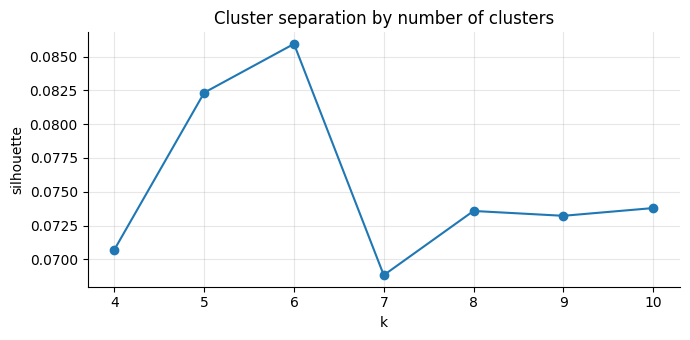

In [3]:
CLUSTER_FEATURES = (["wallet_share", "evening_share", "weekend_share", "abroad_share", "n_store_categories"]
                    + [f"s_{g}" for g in GROUPS if g not in ("money_transfer",)])

def cluster_matrix(d):
    X = d[CLUSTER_FEATURES].fillna(0).copy()
    X["log_tx_per_month"] = np.log1p(d.n_store / d.active_months)
    X["log_median_amount"] = np.log1p(d.median_store_amount.fillna(0))
    return X

tr = feat[feat.snapshot == TRAIN_T].reset_index(drop=True)
te = feat[feat.snapshot == TEST_T].reset_index(drop=True)
scaler = StandardScaler().fit(cluster_matrix(tr))
Z_tr = scaler.transform(cluster_matrix(tr))
Z_te = scaler.transform(cluster_matrix(te))

rng = np.random.default_rng(RNG)
sample = rng.choice(len(Z_tr), size=min(40_000, len(Z_tr)), replace=False)
scores = []
for k in range(4, 11):
    km = KMeans(n_clusters=k, n_init=5, random_state=RNG).fit(Z_tr[sample])
    scores.append({"k": k, "silhouette": silhouette_score(Z_tr[sample], km.labels_, sample_size=10_000, random_state=RNG),
                   "inertia": km.inertia_})
scores = pd.DataFrame(scores)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(scores.k, scores.silhouette, "o-")
ax.set_xlabel("k")
ax.set_ylabel("silhouette")
ax.set_title("Cluster separation by number of clusters")
plt.tight_layout()
scores

In [4]:
K = int(scores.sort_values("silhouette", ascending=False).k.iloc[0])
K = max(K, 6)  # at least 6 personas for a useful story
km = KMeans(n_clusters=K, n_init=10, random_state=RNG).fit(Z_tr)
tr["cluster"] = km.predict(Z_tr)
te["cluster"] = km.predict(Z_te)

# Stability: same cards, clusters from train-window features vs test-window features
both = tr[["card", "cluster"]].merge(te[["card", "cluster"]], on="card", suffixes=("_tr", "_te"))
km_te = KMeans(n_clusters=K, n_init=10, random_state=RNG).fit(Z_te)
te_refit = pd.Series(km_te.labels_, index=te.card)
print(f"K = {K}")
print(f"same card, same cluster in both windows: {(both.cluster_tr == both.cluster_te).mean():.1%}")
print(f"ARI train-model vs model refit on test window: {adjusted_rand_score(te.cluster, km_te.labels_):.2f}")

K = 6
same card, same cluster in both windows: 73.7%
ARI train-model vs model refit on test window: 0.83


In [5]:
# Cluster profiles (train window): what characterises each cluster vs the average card?
prof_cols = ["wallet_share", "evening_share", "weekend_share", "abroad_share", "n_store_categories", "median_store_amount"] + \
            [f"s_{g}" for g in GROUPS]
prof = tr.groupby("cluster")[prof_cols].mean()
prof["tx_per_month"] = (tr.n_store / tr.active_months).groupby(tr.cluster).mean()
avg = tr[prof_cols].mean()
avg["tx_per_month"] = (tr.n_store / tr.active_months).mean()

# Top 4 distinctive features per cluster (ratio to the average)
ratio = prof / avg
def describe(c):
    r = ratio.loc[c].drop(["n_store_categories", "median_store_amount", "tx_per_month"]).sort_values(ascending=False)
    return ", ".join(f"{k.replace('s_', '')} x{v:.1f}" for k, v in r.head(4).items())

outcome = tr.groupby("cluster").agg(
    cards=("card", "size"),
    online_user_pct=("online_before_T", lambda s: s.mean() * 100),
    typed_share_pct=("n_online_typed", lambda s: s.sum() / tr.loc[s.index, "n_online"].sum() * 100),
)
summary = outcome.join(prof[["wallet_share", "tx_per_month", "median_store_amount", "n_store_categories"]])
summary["distinctive"] = [describe(c) for c in summary.index]
summary.sort_values("online_user_pct")

,cards,online_user_pct,typed_share_pct,wallet_share,tx_per_month,median_store_amount,n_store_categories,distinctive
cluster,,,,,,,,
5,202790,36.075,29.120,0.124,16.891,62.431,11.995,"grocery x1.4, weekend_share x0.9, billtelecom_..."
0,79849,44.131,28.074,0.122,13.770,115.022,15.321,"home_electronics x3.2, car_fuel x2.9, other x1..."
2,175187,45.381,33.446,0.123,22.812,84.001,21.801,"fashion_sport x2.1, health_beauty x1.8, hobby_..."
3,15343,67.334,46.839,0.359,18.524,30.147,15.516,"public_transport x16.7, digital_content x16.7,..."
4,24231,79.109,47.973,0.485,14.360,85.916,15.765,"abroad_share x17.5, travel x7.2, digital_conte..."
1,183681,84.128,52.380,0.739,27.925,41.392,21.172,"wallet_share x2.4, fast_food x2.0, entertainme..."


In [6]:
# Business value: can the cluster (from in-store behaviour only) predict who starts online? Never-online cards, test window
nev = te[~te.online_before_T]
rate = nev.groupby("cluster").started_next_3m.agg(["size", "mean"]).rename(columns={"size": "cards", "mean": "start_rate"})
rate["lift"] = rate.start_rate / nev.started_next_3m.mean()
# Use the cluster's start rate from the TRAIN window as its score (no test information)
nev_tr = tr[~tr.online_before_T]
score_map = nev_tr.groupby("cluster").started_next_3m.mean()
auc_cluster = roc_auc_score(nev.started_next_3m, nev.cluster.map(score_map))
print(f"never-online cards in test: {len(nev):,}, start rate {nev.started_next_3m.mean():.1%}")
print(f"AUC of cluster id as the only predictor: {auc_cluster:.3f}")
safe(rate).sort_values("lift", ascending=False)

never-online cards in test: 277,821, start rate 4.7%
AUC of cluster id as the only predictor: 0.598


,cards,start_rate,lift
cluster,,,
1,19875,0.122,2.596
4,3593,0.120,2.544
3,5008,0.082,1.745
2,88992,0.044,0.929
0,37730,0.044,0.929
5,122623,0.035,0.739


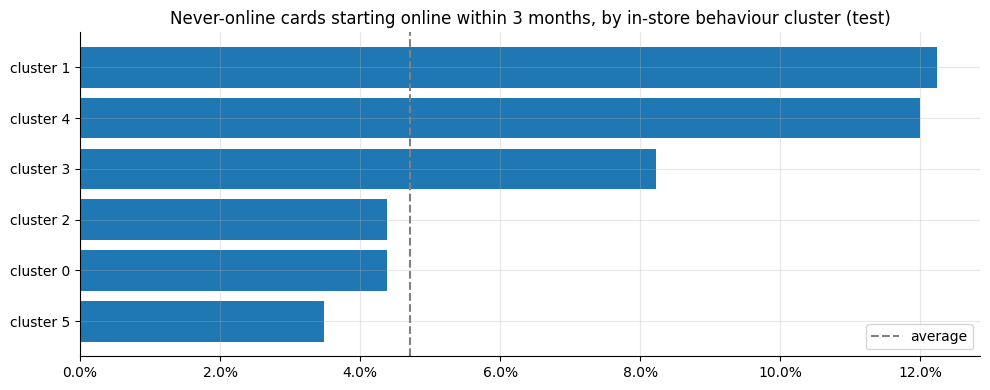

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
r = rate.sort_values("start_rate")
ax.barh([f"cluster {c}" for c in r.index], r.start_rate * 100)
ax.axvline(nev.started_next_3m.mean() * 100, color="grey", ls="--", label="average")
ax.xaxis.set_major_formatter(pct)
ax.set_title("Never-online cards starting online within 3 months, by in-store behaviour cluster (test)")
ax.legend()
plt.tight_layout()

## C. First-purchase recommender

For cards that **start** paying online within 3 months of the snapshot: predict the macro group of their
**first** online purchase from in-store behaviour before T. Compared with a popularity baseline (always recommend
the most common first purchases).

Metric: **top-1 and top-3 hit rate** on the test snapshot.

In [8]:
names = con.sql(f'''
    SELECT DISTINCT mrch_catg_nm AS first_cat, mrch_catg_cd FROM read_parquet('{SLIM}/bucket=0/*.parquet')
''').df().drop_duplicates("first_cat")
con.register("names", names)
fo = con.sql(f"SELECT f.card, {MACRO.replace('mrch_catg_cd', 'n.mrch_catg_cd')} AS first_group, f.first_mode "
             f"FROM first_online f JOIN names n USING (first_cat)").df()

def starters(d):
    s = d[~d.online_before_T & d.started_next_3m].merge(fo, on="card")
    return s[s.first_group != "money_transfer"].reset_index(drop=True)

s_tr, s_te = starters(tr), starters(te)
print(f"starters: train {len(s_tr):,}, test {len(s_te):,}")
dist = (s_tr.first_group.value_counts(normalize=True) * 100).round(1)
dist

starters: train 18,921, test 13,099


first_group
digital_content         34.300
other                   10.700
marketplace_general      8.900
travel                   8.500
home_electronics         6.700
fashion_sport            5.400
taxi                     5.200
bills_telecom_edu        4.000
entertainment_betting    3.800
public_transport         3.400
fast_food                2.000
car_fuel                 1.900
health_beauty            1.600
hobby_books_gifts        1.300
restaurants_bars         1.200
grocery                  1.100
Name: proportion, dtype: float64

In [9]:
REC_FEATURES = CLUSTER_FEATURES + ["card_age_months"]
Xtr = s_tr[REC_FEATURES].fillna(0).assign(log_tx=np.log1p(s_tr.n_store / s_tr.active_months), cluster=s_tr.cluster)
Xte = s_te[REC_FEATURES].fillna(0).assign(log_tx=np.log1p(s_te.n_store / s_te.active_months), cluster=s_te.cluster)
classes = sorted(s_tr.first_group.unique())
ytr = s_tr.first_group.map({c: i for i, c in enumerate(classes)})
yte = s_te.first_group.map({c: i for i, c in enumerate(classes)})
keep = yte.notna()

rec = lgb.LGBMClassifier(objective="multiclass", n_estimators=300, learning_rate=0.05, num_leaves=31,
                         min_child_samples=100, verbose=-1).fit(Xtr, ytr)
proba = rec.predict_proba(Xte[keep])
y_true = yte[keep].astype(int).values

def hit(proba, k):
    top = np.argsort(-proba, axis=1)[:, :k]
    return (top == y_true[:, None]).any(axis=1).mean()

pop = np.tile(s_tr.first_group.value_counts(normalize=True).reindex(classes).fillna(0).values, (len(y_true), 1))
rec_results = pd.DataFrame([
    {"method": "popularity baseline", "top-1": hit(pop, 1), "top-3": hit(pop, 3)},
    {"method": "LightGBM recommender", "top-1": hit(proba, 1), "top-3": hit(proba, 3)},
])
rec_results

,method,top-1,top-3
0,popularity baseline,0.322,0.537
1,LightGBM recommender,0.309,0.537


In [10]:
# Does the recommender personalise? Precision / recall per first-purchase group (test)
pred = np.argmax(proba, axis=1)
per_class = pd.DataFrame({
    "group": classes,
    "cards_true": np.bincount(y_true, minlength=len(classes)),
    "cards_predicted": np.bincount(pred, minlength=len(classes)),
})
per_class["precision"] = [((pred == i) & (y_true == i)).sum() / max((pred == i).sum(), 1) for i in range(len(classes))]
per_class["recall"] = [((pred == i) & (y_true == i)).sum() / max((y_true == i).sum(), 1) for i in range(len(classes))]
per_class["base_rate"] = per_class.cards_true / len(y_true)
per_class["lift"] = per_class.precision / per_class.base_rate
safe(per_class, "cards_true").sort_values("cards_true", ascending=False)

,group,cards_true,cards_predicted,precision,recall,base_rate,lift
2,digital_content,4217,11504,0.333,0.908,0.322,1.034
11,other,1794,364,0.137,0.028,0.137,1.003
15,travel,1267,413,0.225,0.073,0.097,2.328
10,marketplace_general,1022,295,0.092,0.026,0.078,1.173
9,home_electronics,899,175,0.086,0.017,0.069,1.249
14,taxi,643,97,0.134,0.020,0.049,2.730
3,entertainment_betting,584,25,0.000,0.000,0.045,0.000
12,public_transport,539,77,0.065,0.009,0.041,1.578
4,fashion_sport,524,62,0.065,0.008,0.040,1.613
0,bills_telecom_edu,509,55,0.182,0.020,0.039,4.679


## Comparison

Filled in below from the results of A (readiness model notebook), B and C.

In [11]:
comparison = pd.DataFrame([
    {"approach": "A. readiness model (LightGBM)", "finds starters (AUC)": 0.740, "lift top 10%": 3.4,
     "extra output": "ranked list of cards + drivers (SHAP)"},
    {"approach": "B. behavioural clusters", "finds starters (AUC)": round(auc_cluster, 3),
     "lift top 10%": np.nan, "extra output": f"{K} personas, online gap per persona"},
    {"approach": "C. first-purchase recommender", "finds starters (AUC)": np.nan, "lift top 10%": np.nan,
     "extra output": f"top-3 hit {hit(proba, 3):.0%} vs {hit(pop, 3):.0%} popularity"},
])
comparison

,approach,finds starters (AUC),lift top 10%,extra output
0,A. readiness model (LightGBM),0.740,3.400,ranked list of cards + drivers (SHAP)
1,B. behavioural clusters,0.598,NaN,"6 personas, online gap per persona"
2,C. first-purchase recommender,NaN,NaN,top-3 hit 54% vs 54% popularity


## Verdict

| Approach | Finds future online starters | Business output | Verdict |
|---|---|---|---|
| **A. Readiness model** | AUC 0.74, top 10% = 3.4x average | ranked cards + behavioural drivers | **keep: core AI** |
| **B. Behavioural clusters** | AUC 0.60, best clusters 2.6x average | 6 stable personas with very different online usage (36%-84%) | **keep: storytelling layer** |
| C. First-purchase recommender | top-3 hit 54% = popularity baseline | barely personalises (only rare groups) | drop |

**B details.** Silhouette is low (0.07-0.09): behaviour is a continuum, not sharp groups. But clusters are stable
(same card keeps its cluster in 74% of cases across windows, ARI 0.83 vs refit) and interpretable:

| Cluster | Cards | Pay online | Profile (in-store only) |
|---|---|---|---|
| 5 everyday grocery shoppers | 203k | 36% | grocery-heavy, few categories |
| 0 home & car | 80k | 44% | electronics / DIY x3.2, fuel x2.9, highest typical amount |
| 2 mall shoppers | 175k | 45% | fashion x2.1, beauty x1.8, many categories |
| 3 commuters | 15k | 67% | public transport x17, small amounts |
| 4 travellers | 24k | 79% | payments abroad x17, travel x7 |
| 1 digital city dwellers | 184k | 84% | phone wallet 74%, fast food, entertainment |

The biggest gap is in the large "everyday", "home & car" and "mall" clusters (460k cards, 36-45% online). The mall
cluster matches the GUS finding that clothing is where card e-commerce lags the market most.

**Recommendation:** use A to rank cards and B to explain *who* they are (personas on the dashboard, readiness
score within each persona). C does not beat a simple popularity list and is not worth the complexity.
